# BioVision-Path
## Biomedical Cell Object Detection using Faster R-CNN

### OBJECTIVE
This notebook fine-tunes a Faster R-CNN object detector with a MobileNet-V3-Large FPN backbone to localize and classify blood cells.
We will:
1. Parse microscopic smear annotations in PASCAL VOC XML format from the public BCCD dataset.
2. Validate bounding boxes (ensuring min < max and inside image bounds) to prevent training crashes.
3. Fine-tune Faster R-CNN on the blood cells (WBC, RBC, Platelets).
4. Evaluate detector precision and recall using IoU matching, and plot comparison detection overlays.

### 1. Setup & Environment

In [1]:
# Environment Report & CUDA Detection
import sys
import torch
import torchvision
from src.reproducibility import print_environment_report, set_seed
from src.config import CONFIG

# Print report
env = print_environment_report()
set_seed(CONFIG["seed"])


                    ENVIRONMENT REPORT                    
Python Version    : 3.10.9
PyTorch Version   : 2.13.0+cpu
CUDA Available    : False
GPU Name          : None (CPU Fallback)
[Notice] CUDA is not available. System is running in CPU fallback mode.
         In GPU environments (like Colab GPU runtime), this will significantly slow training.
         Please check runtime settings if a GPU was expected.
[Reproducibility] Random seed set to: 42


### 2. Dataset Verification & Parsing

In [2]:
# Parse BCCD annotations
from src.detection import get_bccd_dataloaders, BCCDDataset
import os

bccd_dir = os.path.join(CONFIG["data_dir"], "BCCD")
print(f"BCCD dataset located at: {bccd_dir}")

# Load and split
train_loader, val_loader = get_bccd_dataloaders(
    root_dir=bccd_dir,
    batch_size=CONFIG["detection"]["demo"]["batch_size"] if CONFIG["demo_mode"] else CONFIG["detection"]["full"]["batch_size"],
    target_size=CONFIG["detection"]["image_size"],
    demo_mode=CONFIG["demo_mode"],
    subset_size=CONFIG["detection"]["demo"]["subset_size"]
)

# Verify single batch
images, targets = next(iter(train_loader))
print(f"Batch images count: {len(images)}")
print(f"First image shape : {images[0].shape}")
print(f"First target keys : {targets[0].keys()}")
print(f"First target boxes: {targets[0]['boxes']}")


BCCD dataset located at: data\BCCD
[Dataset] DEMO MODE: Subsetting BCCD dataset. Train: 20, Val: 5
Batch images count: 2
First image shape : torch.Size([3, 480, 640])
First target keys : dict_keys(['boxes', 'labels'])
First target boxes: tensor([[487., 106., 602., 218.],
        [485., 217., 600., 329.],
        [  1., 323., 107., 436.],
        [447., 322., 549., 416.],
        [229.,  56., 331., 150.],
        [  1.,   1.,  77.,  65.],
        [323., 273., 425., 350.],
        [142., 264., 244., 341.],
        [221., 148., 323., 225.],
        [340.,   1., 442.,  77.],
        [185., 352., 288., 440.],
        [ 76., 103., 179., 191.],
        [399., 107., 506., 213.],
        [361., 365., 479., 469.],
        [227., 281., 302., 353.],
        [  1., 199., 121., 316.],
        [532., 298., 558., 325.]])


### 3. Model Loading & Fine-Tuning

In [3]:
# Instantiate detector and run training
from src.models import get_faster_rcnn_mobilenet_v3
from src.training import fit_model
import torch.optim as optim

# 4 classes: background (0), WBC (1), RBC (2), Platelets (3)
detector = get_faster_rcnn_mobilenet_v3(num_classes=4, pretrained=True).to(CONFIG["device"])
optimizer = optim.AdamW(detector.parameters(), lr=1e-4, weight_decay=1e-5)

det_history = fit_model(
    model=detector,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=None, # Faster R-CNN trains on internal loss dicts
    epochs=CONFIG["detection"]["demo"]["epochs"] if CONFIG["demo_mode"] else CONFIG["detection"]["full"]["epochs"],
    device=CONFIG["device"],
    checkpoint_path="checkpoints/faster_rcnn_detection.pth",
    task_type="detection"
)


[Training] Starting training on device: cpu (Task: detection)


Detection Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Detection Batches:  10%|█         | 1/10 [00:03<00:33,  3.70s/it]

Detection Batches:  20%|██        | 2/10 [00:07<00:28,  3.57s/it]

Detection Batches:  30%|███       | 3/10 [00:10<00:24,  3.55s/it]

...

Detection Batches:  80%|████████  | 8/10 [00:28<00:07,  3.64s/it]

Detection Batches:  90%|█████████ | 9/10 [00:32<00:03,  3.70s/it]

Detection Batches: 100%|██████████| 10/10 [00:36<00:00,  3.69s/it]

Epoch 1/1 | Train Loss: 1.7142 | Time: 36.3s


 => State saved! New best loss: 1.7142
[Training] Restoring best checkpoint from: checkpoints/faster_rcnn_detection.pth


### 4. Quantitative & Qualitative Evaluation

In [4]:
# Evaluate detection metrics
from src.evaluation import evaluate_detector
from src.visualization import plot_detection_predictions

det_metrics = evaluate_detector(detector, val_loader, CONFIG["device"], score_threshold=0.5)
print("--- Faster R-CNN Test Detection Metrics ---")
for k, v in det_metrics.items():
    print(f"{k:20s}: {v:.4f}")


--- Faster R-CNN Test Detection Metrics ---
precision           : 0.4324
recall              : 0.6275
f1                  : 0.5120
mean_iou            : 0.7569
total_ground_truths : 51.0000
total_predictions   : 74.0000


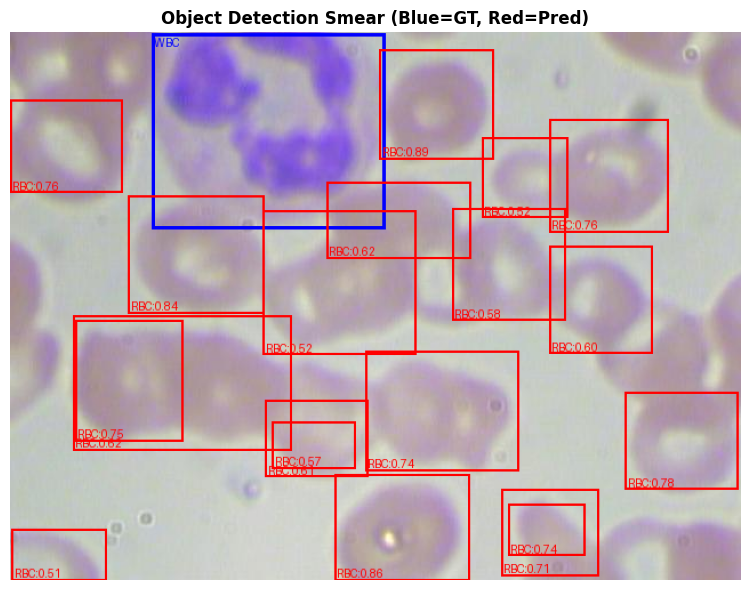

In [5]:
# Plot prediction boxes vs ground truth
detector.eval()
images_val, targets_val = next(iter(val_loader))
with torch.no_grad():
    predictions = detector([img.to(CONFIG["device"]) for img in images_val])

# Plot first 2 examples
plot_detection_predictions(
    images_val[0], 
    targets_val[0], 
    predictions[0], 
    class_names=CONFIG["detection"]["classes"], 
    save_path="outputs/detection/sample_detections_1.png"
)


### 5. Responsible Use & Limitations
- **educational/research purpose**: This notebook trains a smear cell detector and is not medically validated.
- **scanner differences**: Bounding box localization can fail on overlapping/clustered cells or different blood-staining colors.
- **not diagnostic**: The model should not be used as a clinical diagnostic tool for blood count profiling.